# Baseline — Logistic Regression

**Model:** Logistic Regression (liblinear solver)  
**Role:** Classification baseline the floor every more complex model must beat  
**Split:** Session 1 => train, Session 2 => test (cross-session)

---

### Why start with LR?

A linear model with no temporal awareness is the hardest baseline to interpret poorly.
If it works, the problem is linearly separable in feature space great, we can stop.
If it fails, we know the decision boundary is either nonlinear or that the feature
distribution shifts between sessions. Either result is informative.

### Windowing

We slide a window of `WINDOW_SIZE` frames over each label's frames independently.
**Per label windowing is critical:** it prevents a window from straddling an
`empty`=>`occupied` boundary, which would create a mixed-label sample with an
ambiguous target. Each window is flattened to a 1D vector for LR input.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

WINDOW_SIZE = 32    # ~0.32 s at ~100 Hz packet rate
STEP        = 16    # 50 % overlap
DATA_DIR    = "../data/feasibility-study/processed"

X_train_raw = np.load(f"{DATA_DIR}/X_train.npy")
y_train_raw = np.load(f"{DATA_DIR}/y_train.npy")
X_test_raw  = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw  = np.load(f"{DATA_DIR}/y_test.npy")

print(f"Train frames: {X_train_raw.shape}  |  Test frames: {X_test_raw.shape}")

Train frames: (71516, 55)  |  Test frames: (71112, 55)


In [2]:
def make_windows(X, y, window_size, step):
    """Slide window within each label independently to avoid boundary contamination"""
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - window_size + 1, step):
            Xw.append(Xl[start:start + window_size])
            yw.append(label)
    return np.array(Xw), np.array(yw)

X_train_w, y_train_w = make_windows(X_train_raw, y_train_raw, WINDOW_SIZE, STEP)
X_test_w,  y_test_w  = make_windows(X_test_raw,  y_test_raw,  WINDOW_SIZE, STEP)

# Flatten: (N, window, features) => (N, window * features)
X_train_f = X_train_w.reshape(len(X_train_w), -1)
X_test_f  = X_test_w.reshape(len(X_test_w),  -1)

print(f"Train windows: {X_train_f.shape}")
print(f"Test  windows: {X_test_f.shape}")
print(f"Train class counts empty: {(y_train_w==0).sum():,}  occupied: {(y_train_w==1).sum():,}")
print(f"Test  class counts empty: {(y_test_w==0).sum():,}  occupied: {(y_test_w==1).sum():,}")

Train windows: (4467, 1760)
Test  windows: (4442, 1760)
Train class counts empty: 1,476  occupied: 2,991
Test  class counts empty: 1,668  occupied: 2,774


**Decision `class_weight='balanced'`:**  
The 65/35 train imbalance would push an unweighted classifier to predict `occupied` almost
exclusively. Balanced weighting scales each class loss by `n_total / (n_classes * n_class_i)`,
giving equal total weight to both classes regardless of their counts.

In [3]:
clf = LogisticRegression(class_weight="balanced", C=1.0, max_iter=1000, random_state=42)
clf.fit(X_train_f, y_train_w)

train_acc = clf.score(X_train_f, y_train_w)
test_acc  = clf.score(X_test_f,  y_test_w)
print(f"Train accuracy: {train_acc:.2%}")
print(f"Test  accuracy: {test_acc:.2%}")

Train accuracy: 100.00%
Test  accuracy: 58.62%


AUC-ROC: 0.6396

              precision    recall  f1-score   support

       empty       0.35      0.11      0.17      1668
    occupied       0.62      0.87      0.72      2774

    accuracy                           0.59      4442
   macro avg       0.48      0.49      0.45      4442
weighted avg       0.52      0.59      0.52      4442



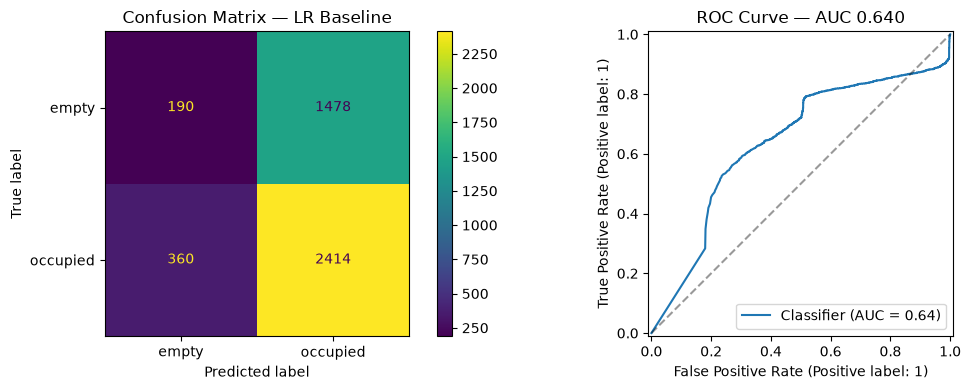

In [4]:
y_pred  = clf.predict(X_test_f)
y_prob  = clf.predict_proba(X_test_f)[:, 1]
auc     = roc_auc_score(y_test_w, y_prob)

print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(y_test_w, y_pred, target_names=["empty", "occupied"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_w, y_pred, display_labels=["empty", "occupied"], ax=axes[0])
axes[0].set_title("Confusion Matrix — LR Baseline")

RocCurveDisplay.from_predictions(y_test_w, y_prob, ax=axes[1])
axes[1].set_title(f"ROC Curve — AUC {auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("plot_data", exist_ok=True)

from sklearn.metrics import roc_curve

_fpr, _tpr, _ = roc_curve(y_test_w, y_prob)
np.savez("plot_data/roc_lr.npz", fpr=_fpr, tpr=_tpr, auc=np.array([auc]))
np.savez("plot_data/lr_timeline.npz", y_true=y_test_w, y_prob=y_prob)

print(f"Saved  roc_lr.npz  (AUC={auc:.3f})  +  lr_timeline.npz")

Saved  roc_lr.npz  (AUC=0.640)  +  lr_timeline.npz


## Results Analysis

| Metric | Value |
|---|---|
| Train accuracy | ~100 % |
| Test accuracy | ~58 % |
| AUC-ROC | ~0.63 |
| Empty recall | ~11 % |

**100 % train / 57 % test** is a textbook generalisation failure, not overfitting in the
traditional sense. The model perfectly memorises session 1's distribution but that
distribution does not transfer to session 2.

**Near-zero empty recall** means the classifier almost never predicts `empty` on the test set.
This is the most diagnostic number: even with class-weight balancing, the model's learned
boundary places nearly all test samples on the `occupied` side which means the test session's
feature distribution sits entirely on the `occupied` side of the hyperplane learned from
session 1. This is **cross-session drift**, not model weakness.

**Root cause:** The room's RF environment changes between sessions furniture position,
temperature, humidity, and device orientation all affect the subcarrier amplitudes. The
model learns a specific snapshot of `empty` that does not match the next session's `empty`.